Project 3 Jupyter Notebook
========

### Group: Engel
Authors: Ivan Chan, Kira Obsitnik, Edward Shen, Sage Tulabing, Yuheng Wang, Yixiao Yang


In this notebook, we will estimate a Constant Frisch Elasticity (CFE) demand system and discuss the landscape of the nutritional diet and its adequacy using a set of procedures discussed in the previous lecture. 

This project will use the household food expenditure data in 2019 from **Senegal**, and the Food Nutritional Table (FCT) Spreadsheet that we constructed based on the information provided in the FAO/INFOODS Food Composition Table for Western Africa (WAFCT) 2019 and the USDA FDC Database.

### Set up & Imports
Below are all necessary imports and pip installs for the rest of this project. 

**Please ensure all neccessary files are in the folder before running the below pip install.**

In [1]:
%pip install -r requirements-estimation.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from ligonlibrary.sheets import read_sheets
import matplotlib.pyplot as plt
from cfe import Regression
import cfe

## Population & Data, <span style="color: red;">*Deliverable [A] Choice of population, with supporting expenditure data* <a name="population-f"></span></a>

We decided to focus on Senegal and the effects that household gender ratios have on food expenditures and nutritional adequacy.  We were able to find a study on men’s daily intake; however, most of these men came from households where women did the cooking.  So, we are going to explore how gender might influence food demand and expenditures for the various main food groups.

The data is stored in a Google Spreadsheet: [https://docs.google.com/spreadsheets/d/1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo/](https://docs.google.com/spreadsheets/d/1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo/). It is also available in a local Excel file `Senegal Data.xlsx`.

We will use the following sheets:
* `Household Characteristics` - One row per household, with demographic columns(household members by characteristics, age/sex group, and log household size).
* `Food Expenditures (2019)` - Records of household food expenditures
* `FCT` - Food Nutrition Table, which stores the nutritional information for every unique food item that appeared in the `Food Expenditures` sheet.
* `RDI` - Recommended Dietary Intake, which stores the Recommended Dietary Intake for age/sex group.
and more...

The first two sheets share the index columns `i` (household ID), `t` (survey wave), and `m` (market/region).

In [3]:
Senegal_Data = '1EpdHRbr4QCk_R_uD3kYjo9ZfxOdrX2sFXBsA7xD6vXo'

**To avoid memory issue in Datahub, we only used urban regions for the remaining analysis.**

In [4]:
x = read_sheets(Senegal_Data,sheet='Food Expenditures (2019)')

d = read_sheets(Senegal_Data,sheet="Household Characteristics")
d.columns.name = 'k'

# Data comes in long format; pivot to wide (one column per food)
x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
x = x.replace(0,np.nan) # Replace zeros with missing

# Take logs of expenditures; call this y
y = np.log(x)

d.set_index(['i','t','m'],inplace=True)

# NaN in demographic columns means zero people in that category
d = d.fillna(0)
d = d.loc[(slice(None), 2019, slice(None)), :]
y = y.loc[(slice(None), 2019, slice(None)), :]

# Uncomment this code to fix the memory issue
#d = d.loc[(slice(None), 2019, ['dakar', 'diourbel', 'SAINT-LOUIS', 'thies']), :]
#y = y.loc[(slice(None), 2019, ['dakar', 'diourbel', 'SAINT-LOUIS', 'thies']), :]

### Household characteristics dataframe (d)
Missing values in demographic columns are treated as zero (no members of that age/sex group).

In [5]:
print(f"d shape: {d.shape}")
d.head()

d shape: (3510, 19)


,,k,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize
i,t,m,,,,,,,,,,,,,,,,,,,
21001,2019,ziguinchor,1,1,2,1,1,0,1,0,0,1,0,0,0,1,1,0,0,0,1.609438
210010,2019,ziguinchor,3,6,5,2,3,1,2,1,0,3,1,1,0,0,0,3,1,0,2.772589
210011,2019,ziguinchor,3,5,3,3,2,2,0,1,0,2,1,0,1,2,2,1,0,0,2.639057
210012,2019,ziguinchor,1,2,0,1,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1.386294
21002,2019,ziguinchor,2,4,4,2,1,2,0,1,2,1,1,0,1,1,0,1,1,0,2.484907


### Log-expenditure dataframe (y)

In [6]:
print(f"y shape (households × foods): {y.shape}")
y.head()

y shape (households × foods): (3537, 134)


,,j,"Abats et tripes (foie, rognon, etc.)",Ail,Ananas,Arachide grillée,Arachides décortiquées ou pilées (noflaye),Arachides fraîches en coques,Arachides séchées en coques,"Arôme (Maggi, Jumbo, etc.)",Attiéke,"Aubergine, Courge/Courgette",...,Thé,Tomate fraîche,Tomate séchée,Viande d'autres volailles domestiques,Viande de b__uf,Viande de chèvre,Viande de mouton,Viande de porc,Viande de poulet,Vinaigre /moutarde
i,t,m,,,,,,,,,,,,,,,,,,,,,
221,2019,dakar,7.600902,4.605170,NaN,NaN,6.214608,NaN,NaN,NaN,NaN,4.605170,...,4.60517,6.214608,NaN,NaN,8.006368,NaN,8.160518,NaN,7.824046,6.214608
222,2019,dakar,NaN,5.298317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.605170,...,NaN,4.605170,NaN,NaN,7.313220,NaN,NaN,NaN,NaN,NaN
223,2019,dakar,NaN,3.912023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.912023,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,2019,dakar,6.620073,4.605170,NaN,NaN,NaN,NaN,7.495542,NaN,NaN,NaN,...,NaN,5.298317,NaN,NaN,8.006368,NaN,8.160518,NaN,7.824046,NaN
225,2019,dakar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Estimation

**The following description is adapated from the lecture.**

Let $y_{i}^j$ be log expenditures on food $j$ by household $i$ at a particular time.  We want to estimate a regression that takes the form
$$
      y^j_{i} = A^j(p) + \gamma_j'd_i + \beta_j w_i + \zeta^j_i.
$$
So, a first step is to turn our dataframe for `y` into a series, so we can put it on the left-hand side of this regression.  Then we need to make our dataframe $d$ conform:



In [7]:
y = y.stack().dropna()

d = d.stack().dropna()

# Check that indices are in right places!
assert y.index.names == ['i','t','m','j']
assert d.index.names == ['i','t','m','k']

To set up and run the regression:

In [8]:
import gc

# Delete the large raw DataFrame to free up RAM
del x 
gc.collect() # Force Python to clear the memory

# Now run your CFE model
result = Regression(y=y,d=d)

**If the code below does not run and stopped the kernal, consider **

In [9]:
result.predicted_expenditures()

i       t     m        j                                                                  
221     2019  dakar    Ail                                                                     162.978619
                       Arachides décortiquées ou pilées (noflaye)                              383.303221
                       Aubergine, Courge/Courgette                                             122.734276
                       Autre légumes frais n.d.a (y compris les fleurs blanches de bissap)     168.541336
                       Autres condiments (poivre etc.)                                         149.100599
                                                                                                 ...     
259812  2019  sedhiou  Thé                                                                     147.076215
                       Tomate fraîche                                                          137.005439
                       Viande de b__uf                       

Now we can compare predicted log expenditures with actual:

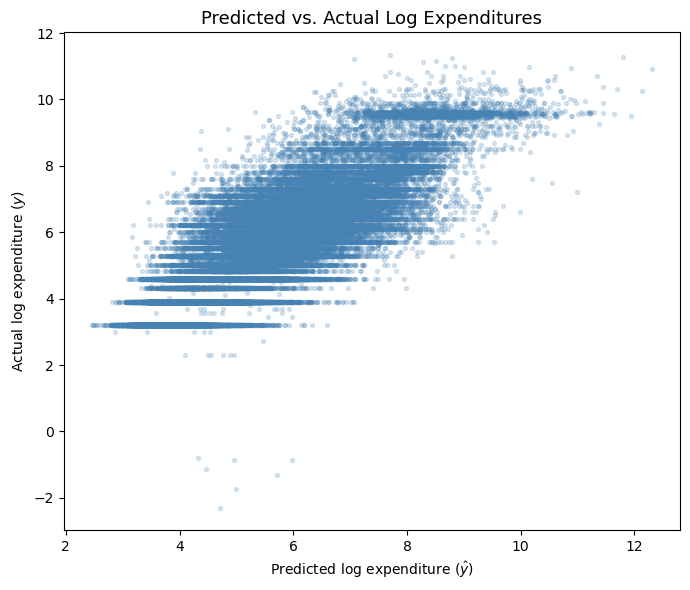

In [10]:
%matplotlib inline

df_fit = pd.DataFrame({
    'y'   : y,
    'yhat': result.get_predicted_log_expenditures()
})

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_fit['yhat'], df_fit['y'], alpha=0.2, s=8, color='steelblue')

ax.set_xlabel('Predicted log expenditure ($\\hat{y}$)')
ax.set_ylabel('Actual log expenditure ($y$)')
ax.set_title('Predicted vs. Actual Log Expenditures', fontsize=13)
plt.tight_layout()
plt.show()

## Demand System, <span style="color: red;">*Deliverable [A] Estimate Demand System* <a name="population-f"></span></a>

Now that we have completed the estimation above, we can then proceed to develop a Demand System.

### Frisch elasticities
Some of the parameters have an interesting interpretation.  First among these are the $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.


In [11]:
result.get_beta().sort_values()

j
Salade (laitue, batavia, etc.)                                         0.351737
Pain moderne                                                           0.519789
Biscuits                                                               0.596902
Arachides décortiquées ou pilées (noflaye)                             0.619441
Poisson frais yaboy ou obo (sardinelle)                                0.619777
Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)    0.637719
Boissons gazeuses (coca, etc.)                                         0.700841
Viande de poulet                                                       0.724159
Feuilles d'oseille (bissap)                                            0.724300
Mil                                                                    0.734125
Pâtes alimentaires                                                     0.795971
Concombre                                                              0.833514
Thé                                   

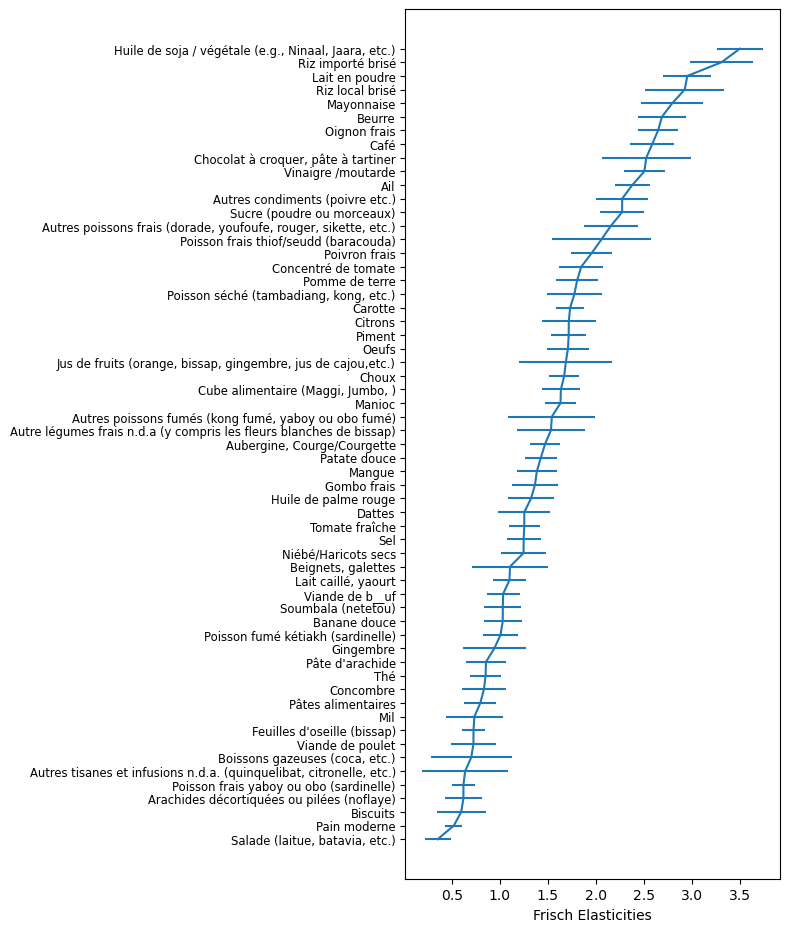

In [12]:
result.graph_beta()
plt.show()

### Household composition effects
These numbers summarize how household demographic composition shifts demand for each food, based on total expenditure. Each row is a food; each column is a demographic characteristic.

These are captured by the $\gamma_j$ parameters in the regression.

In [13]:
result.gamma

k,women,girls,boys,men,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51+,Females 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,,,,,
Ail,-0.215081,-0.337796,-0.096672,-0.023279,0.050224,0.325735,0.100605,0.320946,0.056386,0.304468,0.083070,0.296566,0.061662,0.285235,0.071614,0.328720,0.061886,0.272947,-0.068889,4.210976
Arachides décortiquées ou pilées (noflaye),0.019658,0.024038,-0.026549,0.033819,0.089049,-0.016379,0.095523,0.007988,0.006790,0.018837,0.073381,-0.037100,-0.003759,-0.007562,0.008581,0.057470,0.012542,0.025384,-0.077544,5.387297
"Aubergine, Courge/Courgette",0.255445,0.282211,-0.012188,0.078078,0.007509,-0.269029,0.045170,-0.266101,0.036177,-0.301069,0.007836,-0.311236,-0.051096,-0.202243,-0.050115,-0.204294,-0.003306,-0.222139,0.002499,4.517696
Autre légumes frais n.d.a (y compris les fleurs blanches de bissap),0.312008,0.273223,-0.105439,0.179143,0.087319,-0.320090,0.064454,-0.368693,0.113331,-0.103613,-0.006380,-0.295637,-0.172072,-0.311049,-0.061986,-0.311769,0.051713,-0.355628,-0.021036,4.374436
Autres condiments (poivre etc.),1.678952,1.712768,-1.046630,-0.914000,1.035667,-1.762722,1.089564,-1.778660,0.993875,-1.743612,1.040798,-1.712038,0.885630,-1.593562,0.938419,-1.527713,0.948740,-1.555012,-0.052841,4.071807
"Autres poissons frais (dorade, youfoufe, rouger, sikette, etc.)",-0.711097,-0.822833,-0.067060,0.033364,-0.009933,0.807150,-0.055654,0.726694,0.050189,0.750801,-0.023278,0.768357,-0.055170,0.730834,0.053700,0.861969,0.010630,0.894985,0.007816,6.834060
"Autres poissons fumés (kong fumé, yaboy ou obo fumé)",-0.204823,0.230278,0.036010,0.063896,-0.193348,-0.290257,-0.060337,-0.350963,-0.119321,-0.134982,0.059327,-0.313169,0.036859,0.336153,0.167490,0.416621,0.212716,0.367272,-0.365628,5.691938
"Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)",0.093422,-0.044391,-0.024607,0.088375,0.086043,0.088507,0.003484,0.021414,-0.014718,0.159016,0.074683,-0.080825,-0.054999,-0.008893,-0.116575,-0.042507,0.088753,-0.083326,-0.299800,4.747414
Banane douce,0.077826,-0.080620,-0.095221,0.137522,0.035431,0.090946,0.111496,0.057174,0.146457,0.036117,0.091358,0.128637,-0.189539,-0.057917,-0.160201,-0.122964,0.011016,-0.129211,0.142898,6.078579


## The Code below are still Work In Progress

## Nutritional Adequacy of Diet, <span style="color: red;">*Deliverable [B] Nutritional Adequacy of Diet* <a name="population-f"></span></a>

### Food & Dietary Recommendations

In [14]:
food_df = read_sheets(Senegal_Data,sheet="FCT")
food_df = food_df.set_index('j')
print(food_df.shape)
food_df

(134, 18)


,WAFCT_Code,FDCID,Energy,Protein,Carbohydrate,Fiber,Calcium,Iron,Zinc,Vitamin A,Thiamin,Riboflavin,Niacin,Vitamin B-6,Folate,Vitamin B-12,Vitamin C,Notes
j,,,,,,,,,,,,,,,,,,
Attieke,,2512377.0,357,0.92,87.3,4.8,75.0,3.99,0.41,0.0,0.051,0.068,0.60,0.050,0,0,0.0,"Flour, cassava"
Baby milk and flour,10_011,NaN,519,12.10,55.4,0.0,358.0,9.30,3.90,467.0,0.520,0.780,3.90,0.330,39,1,43.0,"Infant formula, powder, for 3 months, fortified"
Baobab leaves (lalo),04_001,NaN,62,3.90,19.8,42.9,1244.0,13.70,3.56,286.0,0.100,0.150,6.10,1.500,300,0,19.0,"Baobab, feuilles, fraîches, crues"
Bean/cowpea leaves,04_010,NaN,37,4.40,1.7,4.9,258.0,4.90,0.56,407.0,0.200,0.370,2.10,0.240,120,0,57.0,"Niébé, feuilles, fraîches, crues"
Beef,07_023,NaN,174,20.30,0.0,0.0,11.0,1.20,3.43,0.0,0.110,0.110,8.40,0.230,13,1.8,0.0,"Beef meat, ground, ca. 10% fat, raw"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Watermelon, Melon",05_022,NaN,105,0.50,5.0,0.9,7.0,0.30,0.10,50.0,0.030,0.040,0.20,0.070,0,0,6.0,"Watermelon, fruit, raw"
Wheat,01_074,NaN,329,12.00,59.1,12.2,39.0,5.80,2.00,1.0,0.520,0.090,7.80,0.490,40,0,0.0,"Wheat, whole grains, raw"
Whole imported rice,,169707.0,374,7.51,80.9,1.8,71.0,3.33,1.02,0.0,0.603,0.050,5.05,0.452,257,0,0.0,"Rice, white, long-grain, parboiled, enriched, dry"


In [15]:
rdi = read_sheets(Senegal_Data,sheet="RDI")
rdi = rdi.set_index('n')
rdi

,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+
n,,,,,,,,,,,,,,
Energy,1000.0,1000.0,1200.0,1400.0,1600.0,1800.0,1800.0,2200.0,2000.0,2400.0,1800.0,2200.0,1600.0,2000.0
Protein,13.0,13.0,19.0,19.0,34.0,34.0,46.0,52.0,46.0,56.0,46.0,56.0,46.0,56.0
Fiber,14.0,14.0,16.8,19.6,22.4,25.2,25.2,30.8,28.0,33.6,25.2,30.8,22.4,28.0
Folate,150.0,150.0,200.0,200.0,300.0,300.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0,400.0
Calcium,700.0,700.0,1000.0,1000.0,1300.0,1300.0,1300.0,1300.0,1000.0,1000.0,1000.0,1000.0,1200.0,1000.0
Carbohydrate,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0,130.0
Iron,7.0,7.0,10.0,10.0,8.0,8.0,15.0,11.0,18.0,8.0,18.0,8.0,8.0,8.0
Magnesium,80.0,80.0,130.0,130.0,240.0,240.0,360.0,410.0,310.0,400.0,320.0,420.0,320.0,420.0
Niacin,6.0,6.0,8.0,8.0,12.0,12.0,14.0,16.0,14.0,16.0,14.0,16.0,14.0,16.0


In [16]:
# Select Adult 19-30 for our discovery
rdi_adult = rdi[['F 19-30', 'M 19-30']].apply(pd.to_numeric, errors='coerce').mean(axis=1)
rdi_adult.name = 'Daily_RDI_Adult'

# Select only the nutrients that exist in both your RDI and FCT
common_nutrients = list(set(rdi_adult.index) & set(food_df.columns))

# Filter your food_df to just those numeric nutrient columns
food_nutrients = food_df[common_nutrients].apply(pd.to_numeric, errors='coerce')

# Calculate the coverage percentage: (Nutrient in 100g / Daily Adult Need) * 100
coverage_pct = (food_nutrients.div(rdi_adult[common_nutrients], axis=1) * 100).round(2)

print("Percentage of Daily Adult RDI provided by 100g of food:")
coverage_pct

Percentage of Daily Adult RDI provided by 100g of food:


,Vitamin B-6,Fiber,Zinc,Iron,Vitamin B-12,Thiamin,Folate,Energy,Riboflavin,Niacin,Carbohydrate,Vitamin A,Vitamin C,Protein,Calcium
j,,,,,,,,,,,,,,,
Attieke,3.85,15.58,4.32,30.69,0.00,4.43,0.00,16.23,5.67,4.00,67.15,0.00,0.00,1.80,7.5
Baby milk and flour,25.38,0.00,41.05,71.54,41.67,45.22,9.75,23.59,65.00,26.00,42.62,58.38,52.12,23.73,35.8
Baobab leaves (lalo),115.38,139.29,37.47,105.38,0.00,8.70,75.00,2.82,12.50,40.67,15.23,35.75,23.03,7.65,124.4
Bean/cowpea leaves,18.46,15.91,5.89,37.69,0.00,17.39,30.00,1.68,30.83,14.00,1.31,50.88,69.09,8.63,25.8
Beef,17.69,0.00,36.11,9.23,75.00,9.57,3.25,7.91,9.17,56.00,0.00,0.00,0.00,39.80,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Watermelon, Melon",5.38,2.92,1.05,2.31,0.00,2.61,0.00,4.77,3.33,1.33,3.85,6.25,7.27,0.98,0.7
Wheat,37.69,39.61,21.05,44.62,0.00,45.22,10.00,14.95,7.50,52.00,45.46,0.12,0.00,23.53,3.9
Whole imported rice,34.77,5.84,10.74,25.62,0.00,52.43,64.25,17.00,4.17,33.67,62.23,0.00,0.00,14.73,7.1


### Nutrient Adequacy at the **General Adult (19-30)** Level

#### Heatmap for Illustrating % of Adult RDI met by 100g of Each Food Item

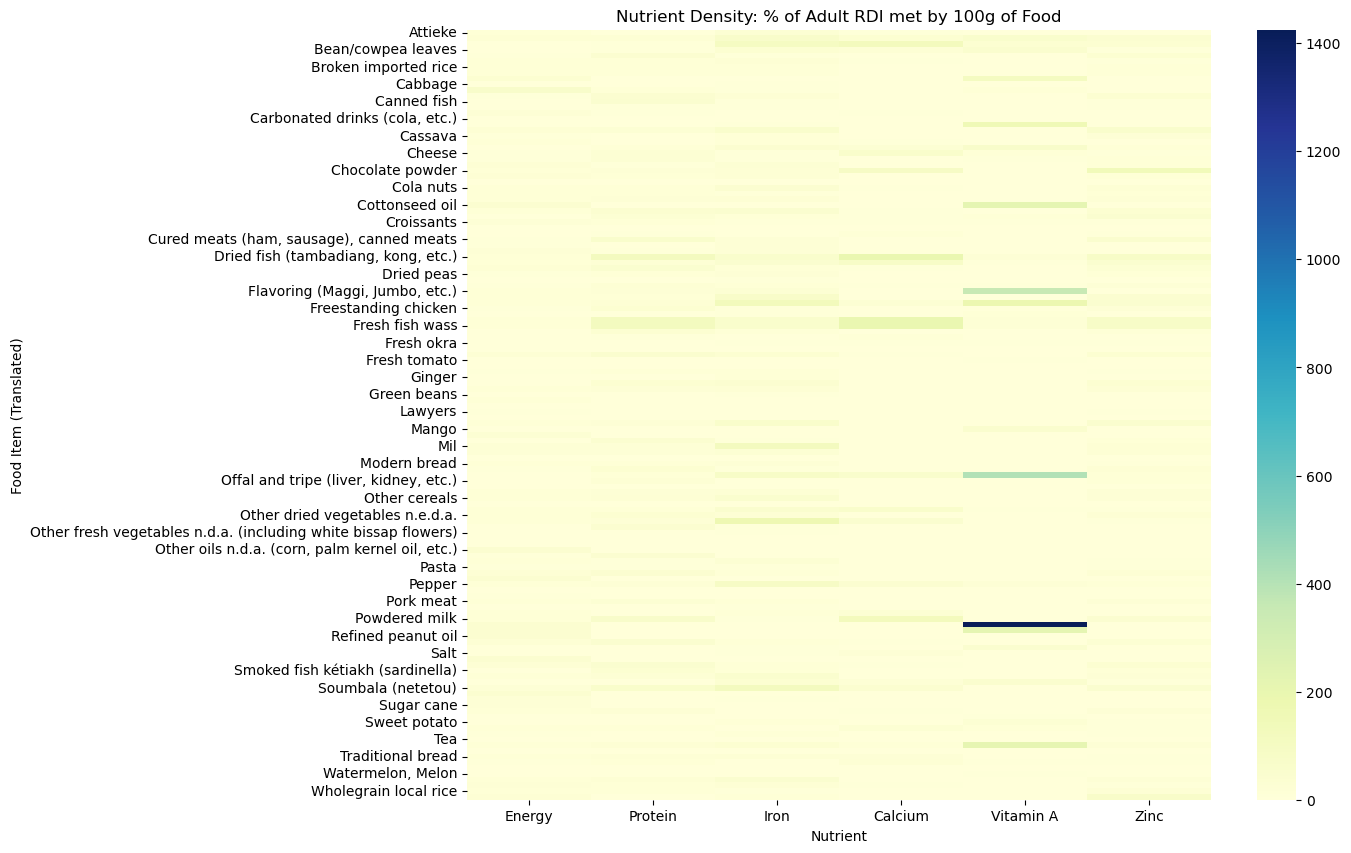

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# You could change the list to the Nutrients you are interested in
target_nutrients = ['Energy', 'Protein', 'Iron', 'Calcium', 'Vitamin A', 'Zinc']

plt.figure(figsize=(12, 10))
sns.heatmap(coverage_pct[target_nutrients], annot=False, cmap='YlGnBu', fmt=".1f")
plt.title("Nutrient Density: % of Adult RDI met by 100g of Food")
plt.ylabel("Food Item (Translated)")
plt.xlabel("Nutrient")
plt.show()

#### Most Nutrient-Efficient Foods for Nutrient Delivery (per 100g)

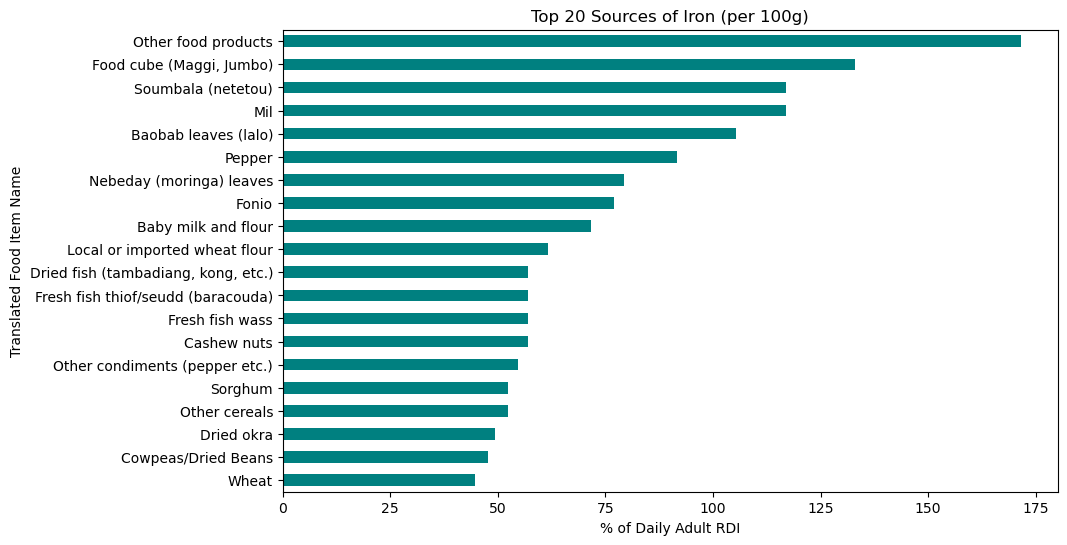

In [37]:
# Change this to whichever nutrient you are interested in
nutrient_to_plot = 'Iron'

top_foods = coverage_pct[nutrient_to_plot].sort_values(ascending=False).head(20)

top_foods.plot(kind='barh', color='teal', figsize=(10, 6))
plt.title(f"Top 20 Sources of {nutrient_to_plot} (per 100g)")
plt.xlabel("% of Daily Adult RDI")
plt.ylabel("Translated Food Item Name")
plt.gca().invert_yaxis() # Highest value at the top
plt.show()

### Nutrient Adequacy at the **Household** Level

#### Food Prices & Expenditures (2019)

In [137]:
p = read_sheets(Senegal_Data, sheet="Food Prices (2019)")

# Filter to only keep the 'standard' units to ensure nutritional accuracy
p_clean = p[p['u_eng'].isin(['Liter', 'kg'])]
p_clean['unit_clean'] = p_clean['u_eng'].str.lower()

# If the list still have duplicates, take the median price for that item/region to remove outliers.
p_final = p_clean.groupby(['m', 'j_eng', 'unit_clean'])['Price'].median().reset_index()

# Compute national median per food + unit
p_final['national_price'] = p_final.groupby(['j_eng', 'unit_clean'])['Price'].transform('median')

# Fill missing prices
p_final['Price'] = p_final['Price'].fillna(p_final['national_price'])

# Drop helper column if needed
p_final = p_final.drop(columns='national_price')
p_final

,m,j_eng,unit_clean,Price
0,SAINT-LOUIS,Beef,kg,2500.000000
1,SAINT-LOUIS,Broken imported rice,kg,357.142857
2,SAINT-LOUIS,Broken local rice,kg,300.000000
3,SAINT-LOUIS,Cabbage,kg,500.000000
4,SAINT-LOUIS,Carrot,kg,400.000000
...,...,...,...,...
1143,ziguinchor,Vinegar/mustard,kg,NaN
1144,ziguinchor,Vinegar/mustard,liter,500.000000
1145,ziguinchor,"Watermelon, Melon",kg,400.000000
1146,ziguinchor,Whole imported rice,kg,14500.000000


In [138]:
# Load the Expenditure data
x = read_sheets(Senegal_Data, sheet="Food Expenditures (2019)")

x = x.groupby(['i', 'm', 'j_eng'])['Expenditure'].sum().reset_index()
x

,i,m,j_eng,Expenditure
0,221,dakar,Beef,3000.0
1,221,dakar,Broken imported rice,400.0
2,221,dakar,Broken local rice,300.0
3,221,dakar,Cabbage,100.0
4,221,dakar,"Caramel, candies, confectionery, etc.",300.0
...,...,...,...,...
93744,259812,sedhiou,Soumbala (netetou),50.0
93745,259812,sedhiou,"Soybean/vegetable oil (e.g., Ninaal, Jaara, etc.)",5000.0
93746,259812,sedhiou,Sugar (powdered or granulated),600.0
93747,259812,sedhiou,Tea,100.0


In [139]:
df = x.merge(p_final, on=['m', 'j_eng'], how='left')
df = df.dropna(subset=['Price'])

# Calculate Quantity
df['quantity'] = df['Expenditure'] / df['Price']

# Standardize Units
df['quantity_g'] = np.where(
    df['unit_clean'] == 'kg',
    df['quantity'] * 1000,
    df['quantity'] * 1000  # assume liter ≈ water for now
)

df

,i,m,j_eng,Expenditure,unit_clean,Price,quantity,quantity_g
0,221,dakar,Beef,3000.0,kg,3000.0,1.000000,1000.000000
1,221,dakar,Broken imported rice,400.0,kg,450.0,0.888889,888.888889
2,221,dakar,Broken local rice,300.0,kg,6750.0,0.044444,44.444444
3,221,dakar,Cabbage,100.0,kg,500.0,0.200000,200.000000
5,221,dakar,Carrot,100.0,kg,400.0,0.250000,250.000000
...,...,...,...,...,...,...,...,...
94557,259812,sedhiou,Red palm oil,250.0,liter,1000.0,0.250000,250.000000
94558,259812,sedhiou,Salt,50.0,kg,50.0,1.000000,1000.000000
94560,259812,sedhiou,Soumbala (netetou),50.0,kg,500.0,0.100000,100.000000
94561,259812,sedhiou,"Soybean/vegetable oil (e.g., Ninaal, Jaara, etc.)",5000.0,liter,1000.0,5.000000,5000.000000


In [140]:
fct_long = fct.reset_index().rename(columns={'j': 'j_eng'})
df = df.merge(fct_long, on='j_eng', how='left')

In [141]:
nutrient_cols = ['Energy', 'Protein', 'Carbohydrate', 'Fiber', 'Calcium',
                 'Iron', 'Zinc', 'Vitamin A', 'Thiamin', 'Riboflavin', 'Niacin',
                 'Vitamin B-6', 'Folate', 'Vitamin B-12', 'Vitamin C']  # adjust to your data

for col in nutrient_cols:
    df[col] = df[col].astype(str).str.replace(',', '').str.strip()

df[nutrient_cols] = df[nutrient_cols].apply(pd.to_numeric, errors='coerce')
df['quantity_g'] = pd.to_numeric(df['quantity_g'], errors='coerce')


for col in nutrient_cols:
    df[col + '_intake'] = df[col] * (df['quantity_g'] / 100)

hh_intake = df.groupby('i')[[col + '_intake' for col in nutrient_cols]].sum()
hh_intake

,Energy_intake,Protein_intake,Carbohydrate_intake,Fiber_intake,Calcium_intake,Iron_intake,Zinc_intake,Vitamin A_intake,Thiamin_intake,Riboflavin_intake,Niacin_intake,Vitamin B-6_intake,Folate_intake,Vitamin B-12_intake,Vitamin C_intake
i,,,,,,,,,,,,,,,
221,74921.187086,3518.341920,7751.514197,1628.442784,43879.568847,769.527317,437.001635,70348.903830,49.312587,75.243680,1499.091898,102.420975,14201.315632,471.529216,3791.593885
222,43833.527145,902.926863,4211.183273,321.759362,8509.413838,223.249782,108.113599,126177.675595,28.334298,19.537172,399.779485,40.200430,8989.505049,101.210000,2012.726190
223,7533.698413,598.867411,559.697718,60.514484,4985.247520,84.273224,51.457698,3960.409226,1.952768,6.038328,341.651488,35.274866,1026.316468,232.940000,426.035714
224,59936.220779,1943.789692,5428.258214,703.150000,9652.267857,301.722386,216.920617,32906.809253,30.440818,34.103920,1000.476753,50.133391,8111.277597,67.583312,2472.589286
225,442.166667,12.633333,82.250000,9.000000,402.333333,1.266667,2.560000,191.000000,0.153333,0.631667,3.133333,1.581667,74.166667,1.333333,47.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259611,6673.297619,162.875000,613.472619,234.514286,7974.250000,88.165476,18.935714,610.000000,1.100714,1.508095,90.207143,8.753571,499.678571,41.500000,403.750000
259612,194307.223495,5160.024665,31851.419770,6291.671520,51143.037358,7071.429322,1225.921003,42225.522876,130.265690,98.823075,2003.008222,184.828287,69769.955659,100.647059,1134.611111
259810,89327.207330,2329.817647,14706.848604,2150.365794,17787.988235,3197.448959,562.476510,36101.356209,61.123206,49.808844,900.431279,83.391754,32765.180345,59.147059,187.861111


In [142]:
d_df = read_sheets(Senegal_Data,sheet="Household Characteristics")
d_df = d_df.set_index('i').drop(columns=['t', 'm'])

def clean_demographic(col):
    col = col.strip()
    
    if col.startswith('Females'):
        return col.replace('Females', 'F')
    elif col.startswith('Males'):
        return col.replace('Males', 'M')
    else:
        return col  # keep others (like women/men if needed)

d_df.columns = [clean_demographic(col) for col in d_df.columns]

In [143]:
d_df.columns = d_df.columns.astype(str)
rdi_df.columns = rdi_df.columns.astype(str)
groups = d_df.columns.intersection(rdi_df.columns)

d_filtered = d_df.reindex(hh_intake.index)[groups].fillna(0)
rdi_filtered = rdi_df[groups]

In [144]:
hh_req_values = d_filtered.values @ rdi_filtered.values.T

hh_requirements = pd.DataFrame(
    hh_req_values,
    index=d_filtered.index,
    columns=rdi_filtered.index
)

hh_intake = hh_intake.copy()
hh_intake.columns = [col.replace('_intake', '') for col in hh_intake.columns]

nar = hh_intake / hh_requirements

In [145]:
#hh_requirements

In [146]:
#hh_intake

In [149]:
nar_clean = nar.dropna(axis=1, how='all')
nar_clean

,Calcium,Carbohydrate,Energy,Fiber,Folate,Iron,Niacin,Protein,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc
i,,,,,,,,,,,,,,,
221,4.100894,5.962703,4.116549,6.391063,3.944810,7.619082,11.022735,7.888659,7.032120,4.787630,9.770681,21.830056,8.064644,5.416563,5.023007
222,1.418236,5.398953,4.764514,2.498132,5.448185,3.659832,6.246554,4.828486,3.907434,5.782510,38.235659,10.223232,7.584987,7.319004,2.702840
223,1.038593,1.076342,1.076243,0.617495,0.733083,2.006505,6.570221,3.742921,1.509582,0.488192,1.523234,27.730952,7.348930,1.775149,1.608053
224,3.217423,13.918611,9.667132,8.100806,6.759398,6.857327,22.738108,13.133714,9.743977,8.953182,14.307308,9.386571,12.854716,10.302455,8.034097
225,0.182879,0.316346,0.130049,0.189076,0.092708,0.048718,0.111905,0.137319,0.287121,0.069697,0.136429,0.277778,0.564881,0.317778,0.160000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259611,1.049243,0.674146,0.538169,1.350889,0.227127,1.259507,1.048920,0.616951,0.225089,0.169341,0.135556,3.143939,1.167143,1.022152,0.338138
259612,3.432419,16.334061,8.674430,20.062728,17.017062,46.522561,12.839796,11.441296,8.100252,10.765760,5.345003,4.091344,13.690984,1.719108,13.041713
259810,8.893994,56.564802,23.507160,40.420410,40.956475,122.978806,30.014376,22.841349,20.753685,26.575307,22.563348,12.322304,27.797251,1.138552,29.604027
